# Project 1: Fast Food Marketing Campaign A/B Test

**Objective**: Evaluate which of 3 marketing promotions drives the highest sales for a new fast-food item.

**Type**: Confirmatory Data Analysis (CDA)

**Dataset**: `WA_Marketing-Campaign.csv` — weekly sales across multiple store locations over 4 weeks.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, levene, f_oneway, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd

pd.set_option('display.max_columns', None)
np.random.seed(42)

## 1. Load & Validate

In [3]:
df = pd.read_csv('WA_Marketing-Campaign.csv')
print(df.shape)
df.head()

(548, 7)


,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
0,1,Medium,1,4,3,1,33.73
1,1,Medium,1,4,3,2,35.67
2,1,Medium,1,4,3,3,29.03
3,1,Medium,1,4,3,4,39.25
4,1,Medium,2,5,2,1,27.81


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 548 entries, 0 to 547
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MarketID          548 non-null    int64  
 1   MarketSize        548 non-null    object 
 2   LocationID        548 non-null    int64  
 3   AgeOfStore        548 non-null    int64  
 4   Promotion         548 non-null    int64  
 5   week              548 non-null    int64  
 6   SalesInThousands  548 non-null    float64
dtypes: float64(1), int64(5), object(1)
memory usage: 30.1+ KB


In [5]:
df.isnull().sum()

MarketID            0
MarketSize          0
LocationID          0
AgeOfStore          0
Promotion           0
week                0
SalesInThousands    0
dtype: int64

In [6]:
df.describe()

,MarketID,LocationID,AgeOfStore,Promotion,week,SalesInThousands
count,548.000000,548.000000,548.000000,548.000000,548.000000,548.000000
mean,5.715328,479.656934,8.503650,2.029197,2.500000,53.466204
std,2.877001,287.973679,6.638345,0.810729,1.119055,16.755216
min,1.000000,1.000000,1.000000,1.000000,1.000000,17.340000
25%,3.000000,216.000000,4.000000,1.000000,1.750000,42.545000
50%,6.000000,504.000000,7.000000,2.000000,2.500000,50.200000
75%,8.000000,708.000000,12.000000,3.000000,3.250000,60.477500
max,10.000000,920.000000,28.000000,3.000000,4.000000,99.650000


## 2. Exploratory Analysis

### Sales distribution by promotion

C:\Users\MA\AppData\Local\Temp\ipykernel_17936\201531610.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(


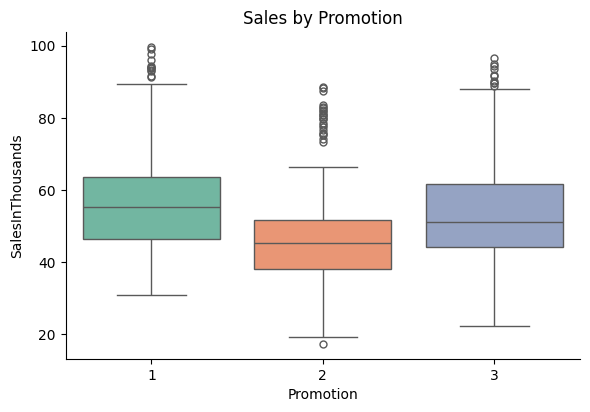

In [7]:
sns.catplot(
    data=df, x='Promotion', y='SalesInThousands',
    kind='box', palette='Set2', height=4, aspect=1.5
)
plt.title('Sales by Promotion')
plt.show()

In [8]:
df.groupby('Promotion')['SalesInThousands'].agg(['mean', 'median', 'std']).round(2)

,mean,median,std
Promotion,,,
1,58.10,55.39,16.55
2,47.33,45.39,15.11
3,55.36,51.16,16.77


### Weekly sales trend per promotion (small multiples)

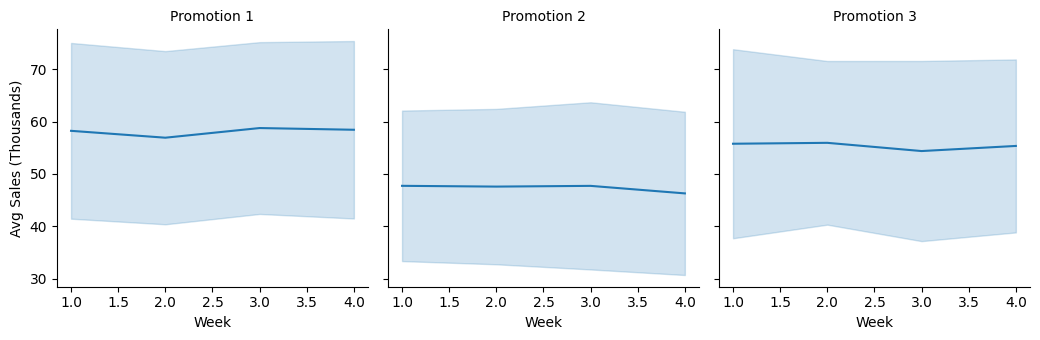

In [9]:
g = sns.FacetGrid(df, col='Promotion', height=3.5, aspect=1)
g.map_dataframe(sns.lineplot, x='week', y='SalesInThousands', estimator='mean', errorbar='sd')
g.set_axis_labels('Week', 'Avg Sales (Thousands)')
g.set_titles('Promotion {col_name}')
plt.show()

### Sales by promotion and market size

c:\Users\MA\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\MA\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\MA\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)


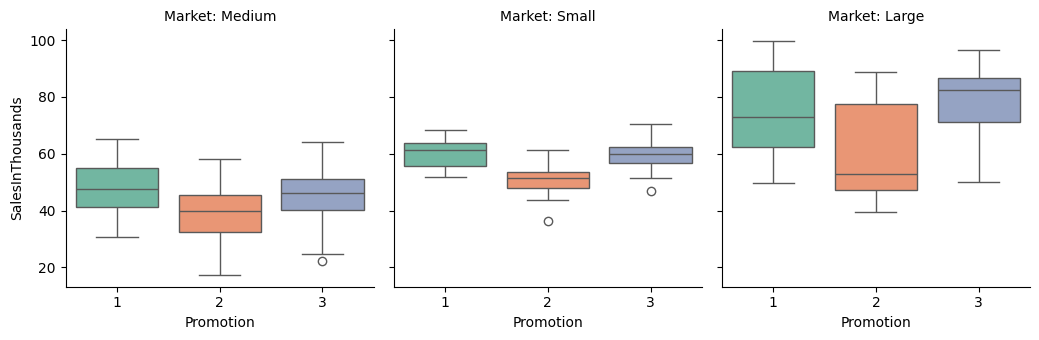

In [10]:
g = sns.FacetGrid(df, col='MarketSize', height=3.5, aspect=1)
g.map_dataframe(sns.boxplot, x='Promotion', y='SalesInThousands', palette='Set2')
g.set_titles('Market: {col_name}')
plt.show()

## 3. Hypothesis Testing

**H0**: There is no significant difference in sales across the three promotions.

**H1**: At least one promotion drives significantly different sales.

**alpha** = 0.05

### Check assumptions (normality + equal variances)

In [16]:
promotion_stats = df.groupby('Promotion')['SalesInThousands'].describe()
print(promotion_stats)

           count       mean        std    min      25%     50%      75%    max
Promotion                                                                     
1          172.0  58.099012  16.553782  30.81  46.3525  55.385  63.6175  99.65
2          188.0  47.329415  15.108955  17.34  38.1700  45.385  51.7450  88.64
3          188.0  55.364468  16.766231  22.18  44.1975  51.165  61.7325  96.48


### Post-hoc: Tukey HSD

Tells us *which* promotions differ significantly from each other.

In [ ]:
tukey_data = df[['Promotion', 'SalesInThousands']]

tukey_result = pairwise_tukeyhsd(endog=tukey_data['SalesInThousands'],
 groups=tukey_data['Promotion'],
 alpha=0.05)

# Show the results of the Tukey's HSD test
print(tukey_result)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     1      2 -10.7696    0.0 -14.7738 -6.7654   True
     1      3  -2.7345 0.2444  -6.7388  1.2697  False
     2      3   8.0351    0.0   4.1208 11.9493   True
-----------------------------------------------------


From the summary table output of the Tukey-HSD test. we can see that the p-values for the pairs '1 & 2' and '2 & 3' is less than 0.05. However, p-value for the pair '1 & 3' is greater than 0.05. As a result, at 95% confidence level, we can say that promotion 2 has a different effect on sales as compared to promotion 1 and promotion 3

## 4. Summary

### Key Findings

- **Best Promotion**: Promotion 1 had the highest mean sales ($58.10K) and median ($55.39K), followed by Promotion 3 ($55.36K mean), and Promotion 2 was the weakest ($47.33K mean).

- **Tukey HSD Results**:
  - Promotion 1 vs Promotion 2: significant difference (p < 0.05, reject = True) — Promotion 1 outperformed Promotion 2 by ~$10.77K
  - Promotion 2 vs Promotion 3: significant difference (p < 0.05, reject = True) — Promotion 3 outperformed Promotion 2 by ~$8.04K
  - Promotion 1 vs Promotion 3: **no significant difference** (p = 0.244, reject = False)



### Recommendation

Promotion 1 for the new menu item rollout. Although Promotion 1 and Promotion 3 are statistically indistinguishable, Promotion 1 has a slightly higher mean and median sales, making it the safer choice. Promotion 2 should be dropped as it significantly underperforms both alternatives.
